# Predicting Student Academic Performance: The Role of Study Habits, Attendance, and AI Tool Usage

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public, including the names of the authors.

* [  ] YES - make available
* [ X ] NO - keep private

## Link to video
https://link.to.your.publicly.viewable.video

## Abstract

Academic performance is shaped by a mix of student behaviors, demographics, and the use of AI-powered tools. This project investigates which factors are most predictive of student academic outcomes using two complementary datasets. The first dataset (Student Performance Dataset) contains high-school-level student records with GPA as the outcome variable. The second dataset (AI Impact on Student Performance) captures how AI tools interact with study behaviors and final scores.

We performed exploratory data analysis (EDA) including scatter plots, correlation matrices, and group comparisons to identify the most important predictors. We then fit Ordinary Least Squares (OLS) regression models to formally test associations and quantify effect sizes. Key findings include: absences are by far the strongest negative predictor of GPA, study time shows a statistically significant but modest positive association, simply using AI tools shows no significant association with final scores, but the *percentage of AI-generated assignment content* is a significant negative predictor, and conceptual understanding of course material is the single strongest predictor of final scores in the AI dataset.

Together, these results suggest that consistent attendance and genuine mastery of material matter most for academic success, while heavy reliance on AI-generated content may undermine performance.

## Authors

- Shaila Valenzuela : dataset cleaning, EDA dataset #1, video editing & speaking
- Nicholas Nurwinata : dataset cleaning
- Khuyen Lai
- Weng Lok

## Research Question

How do student demographics, study habits, and non-academic behaviors relate to academic performance (e.g., semester grades) in a recent higher-education context? Specifically, which factors (attendance, study preparation time, gaming habits, family income, etc.) are most predictive of a student’s final GPA, and can we build a predictive model that outperforms a simple baseline? This is a regression problem where the outcome variable will be GPA or equivalent grade metrics, and predictors include socio-economic and behavior attributes. The research will include controlling for confounders such as department/major and gender. It will explore both statistical significance of variables and predictive power via machine learning models.

## Background and Prior Work

Academic performance in higher education is influenced by a mix of student habits, demographic characteristics, and lifestyle behaviors. We define academic success using quantitative measures such as GPA or final course grades. GPA is not only important within the academic environment but is also connected to future opportunities such as graduate school admissions and job offers. Employer surveys indicate that GPA has historically been used as an initial screening tool in entry-level hiring, meaning that stronger academic performance can increase access to early career opportunities, even as some employers shift toward skills-based hiring practices ([NACE, 2023](https://www.naceweb.org/talent-acquisition/trends-and-predictions/nearly-two-thirds-of-employers-use-skills-based-hiring-practices-for-new-entry-level-hires?utm_source=chatgpt.com)). Understanding what influences academic performance may therefore help students improve both academic and post-graduate outcomes. Prior research suggests that both academic behaviors and non-academic factors, such as sleep patterns or leisure activities, play roles in shaping student outcomes, though the relative strength of these influences varies by context and population.

Studies have consistently shown that class attendance and engagement are strongly associated with higher academic achievement. Research across institutions has found that increased attendance reduces the likelihood of poor academic outcomes such as failing or withdrawing from courses, suggesting that attendance is a strong predictor of academic success ([Credé et al., 2010](https://files.eric.ed.gov/fulltext/EJ1248452.pdf)). In contrast, excessive video game use and screen time have been linked to lower GPA. Research examining video game usage among college students finds that higher levels of gaming are associated with reduced study time and weaker time management skills, which can negatively affect academic performance ([Anand, 2017](https://www.researchgate.net/publication/303226124_The_impact_of_video_games_on_student_GPA_study_habits_and_time_management_skills_What's_the_big_deal)).

Demographic and socioeconomic factors have also been associated with variation in academic performance. Research on socioeconomic status suggests that indicators such as family income and parental education are correlated with GPA, likely because these factors influence access to educational resources, academic support systems, and the amount of time students can devote to studying. These findings highlight the importance of considering both individual behaviors and background characteristics when modeling academic performance, as academic outcomes are shaped by structural as well as personal factors ([Credé et al., 2010](https://files.eric.ed.gov/fulltext/EJ1248452.pdf)).

Non-academic lifestyle factors, particularly sleep and time management, have also been identified as important predictors of academic performance. Studies of college students show that sleep duration and sleep quality are positively associated with GPA, while chronic sleep deprivation is linked to lower academic performance and increased academic stress ([Short et al., 2023](https://www.jahonline.org/article/S1054-139X(23)00373-7/fulltext)). Additionally, research comparing working and non-working students suggests that employment responsibilities can indirectly affect academic outcomes by reducing time available for sleep and study. Together, these findings suggest that lifestyle constraints outside the classroom can meaningfully influence academic success and should be accounted for in analyses of student performance.

## Hypothesis


We hypothesize that students with better academic habits, especially higher attendance and more consistent study time, will have higher grades. We also predict that non-academic behaviors that take time away from schoolwork, for example gaming time and alcohol use, will be negatively associated with GPA. For demographic/socioeconomic factors, we expect them to explain less variation in GPA than academic behaviors. Overall, we expect that a predictive model using these habit variables will show a simple baseline by meaningfully reducing prediction error and that attendance and study time will appear as the most important predictors across models.

## Data

### Data overview

This project uses two complementary publicly available datasets to study academic performance from different angles.

**Dataset 1 — Student Performance Dataset:** Contains 2,392 student records from Kaggle covering demographic characteristics, study habits, parental involvement, extracurricular participation, and GPA. It provides a solid foundation for examining how attendance, study time, and family involvement relate to GPA.

**Dataset 2 — AI Impact on Student Performance Dataset:** Contains 8,000 student records capturing AI tool usage patterns, study behaviors, and academic outcomes (final score). This dataset allows us to test our secondary hypothesis about AI usage and academic performance.

Together, these datasets allow us to examine both traditional academic predictors and the influence of AI tools on student outcomes.

### Dataset #1: Student Performance Dataset

**Source:** Kaggle – Student_performance_data  
https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset

This dataset contains individual-level student records describing demographic characteristics, study habits, parental involvement, extracurricular participation, and academic performance. Each row represents one student, identified by a unique `StudentID` ranging from 1001 to 3392. The dataset includes approximately **2,392 student observations** and **15 variables**.

| Variable | Description |
|---|---|
| `GPA` | Grade Point Average (0–4.0) — our outcome variable |
| `StudyTimeWeekly` | Average hours studied per week (0–20) |
| `Absences` | Number of school absences (0–30) |
| `Tutoring` | Whether the student receives tutoring (0/1) |
| `ParentalSupport` | Level of parental support (0–4) |
| `ParentalEducation` | Highest parental education level (0–4) |
| `Extracurricular`, `Sports`, `Music`, `Volunteering` | Participation in activities |
| `Gender`, `Ethnicity`, `Age` | Background characteristics |

`GradeClass` is excluded from all modeling to prevent target leakage.

**Data wrangling:** The dataset was clean with no missing values. Categorical variables were cast to the `category` dtype. No rows were dropped. The processed dataset is saved to `data/02-processed/students_processed.csv`. For the full wrangling code, see `02-EDACheckpoint.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import ttest_ind
from statsmodels.formula.api import ols
from pathlib import Path
%matplotlib inline

# Load processed Dataset 1
df = pd.read_csv('data/02-processed/students_processed.csv')

# Re-cast categorical columns
cat_cols = ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring',
            'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print('Dataset 1 shape:', df.shape)
df.head()

Dataset 1 shape: (2392, 14)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061


### Dataset 2 — AI Impact on Student Performance Dataset

**Source:** Kaggle – [AI Impact on Students Performance](https://www.kaggle.com/)  
**Size:** 8,000 observations, 26 variables (24 after dropping two non-informative columns)  
**Outcome variable:** `final_score` (continuous, 12.7–95.8)

This dataset focuses on how AI tool usage interacts with study behaviors and academic outcomes. Key variable groups include:

| Variable Group | Key Variables |
|---|---|
| AI Usage | `uses_ai`, `ai_usage_time_minutes`, `ai_dependency_score`, `ai_generated_content_percentage`, `ai_prompts_per_week` |
| Study Behavior | `study_hours_per_day`, `study_consistency_index`, `attendance_percentage`, `class_participation_score` |
| Lifestyle | `sleep_hours`, `social_media_hours`, `tutoring_hours` |
| Academic | `concept_understanding_score`, `improvement_rate`, `final_score` |

`passed` and `performance_category` are excluded from modeling to prevent target leakage. `last_exam_score` and `assignment_scores_avg` are also excluded as they are intermediate performance metrics, not predictors.

**Data wrangling:** `ai_tools_used` and `ai_usage_purpose` were dropped (these were empty for non-AI users, making them non-informative for modeling). No other missing data was found. The cleaned dataset is saved to `data/01-interim/df2_clean.csv`.

In [2]:
# Load processed Dataset 2
df2_clean = pd.read_csv('data/01-interim/students_interim.csv')

print('Dataset 2 shape:', df2_clean.shape)
df2_clean.head()

Dataset 2 shape: (2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


## Results

### Exploratory Data Analysis

The following section presents our EDA findings for both datasets. Rather than reproduce every plot from `02-EDACheckpoint.ipynb`, we focus here on the analyses most relevant to our research question and hypothesis. Key findings from the EDA are organized around four themes: (1) distribution of our outcome variables, (2) the relationship between study habits and academic performance, (3) the role of AI usage, and (4) demographic differences.

> For the complete EDA code and all intermediate plots, see `02-EDACheckpoint.ipynb`.

### EDA 1 — GPA Distribution and Study Habits (Dataset 1)

We begin by examining the distribution of our outcome variable, GPA, and its relationship with our two primary habit predictors: weekly study time and absences.

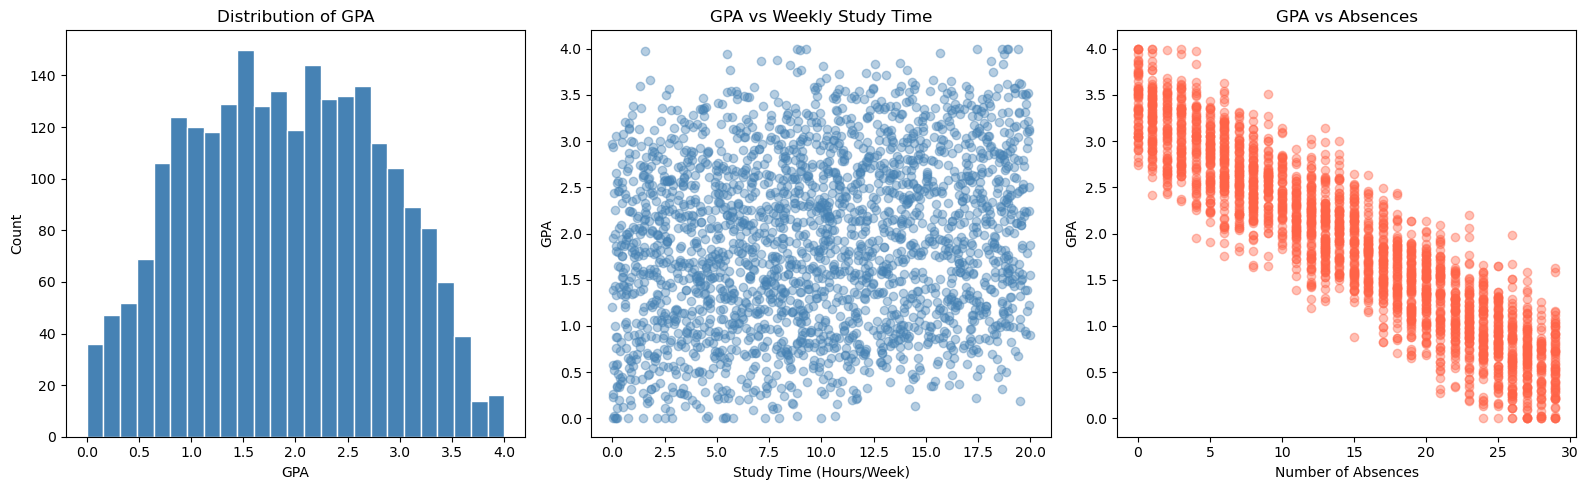

GPA summary stats:
count    2392.000
mean        1.906
std         0.915
min         0.000
25%         1.175
50%         1.893
75%         2.622
max         4.000
Name: GPA, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# GPA distribution
axes[0].hist(df['GPA'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of GPA')
axes[0].set_xlabel('GPA')
axes[0].set_ylabel('Count')

# Study time vs GPA
axes[1].scatter(df['StudyTimeWeekly'], df['GPA'], alpha=0.4, color='steelblue')
axes[1].set_title('GPA vs Weekly Study Time')
axes[1].set_xlabel('Study Time (Hours/Week)')
axes[1].set_ylabel('GPA')

# Absences vs GPA
axes[2].scatter(df['Absences'], df['GPA'], alpha=0.4, color='tomato')
axes[2].set_title('GPA vs Absences')
axes[2].set_xlabel('Number of Absences')
axes[2].set_ylabel('GPA')

plt.tight_layout()
plt.show()

print('GPA summary stats:')
print(df['GPA'].describe().round(3))

**GPA distribution:** GPA ranges from 0 to 4.0 with a mean of approximately 1.91 and a standard deviation of 0.92. The distribution is roughly uniform-to-slightly-right-skewed, confirming that GPA is appropriate for regression modeling.

**Study time vs GPA:** The scatter plot shows a modest positive trend, students who study more hours per week tend to have slightly higher GPAs. However, there is substantial spread at every level of study time, meaning study time alone is not a strong predictor.

**Absences vs GPA:** The relationship between absences and GPA is strikingly strong and negative. Students with high absences cluster strongly at the low end of GPA. This visual pattern is confirmed by the correlation matrix (Pearson r ≈ −0.92), making absences the dominant predictor in this dataset by a wide margin.

### EDA 2 — OLS Regression: Study Time vs GPA (Dataset 1)

To formally test whether study time is a statistically significant predictor of GPA, we run a simple OLS regression with `StudyTimeWeekly` as the sole predictor.

In [4]:
X_study = df[['StudyTimeWeekly']].copy()
X_study = sm.add_constant(X_study)
y_gpa = df['GPA']

ols_study = sm.OLS(y_gpa, X_study).fit()
print(ols_study.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     79.36
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           1.00e-18
Time:                        17:39:29   Log-Likelihood:                -3142.5
No. Observations:                2392   AIC:                             6289.
Df Residuals:                    2390   BIC:                             6300.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.6226      0.037     

**OLS Results — Study Time vs GPA:**

- **Coefficient (β):** The slope for `StudyTimeWeekly` is positive (β ≈ 0.029, p < 0.001), meaning that for each additional hour studied per week, GPA increases by approximately 0.029 points on average. While this is statistically significant, the practical size of the effect is modest.
- **R² ≈ 0.032:** Study time alone explains only about 3.2% of the variance in GPA. The wide scatter in the plot is consistent with this — study time matters, but it is far from the whole story.
- **F-statistic:** Statistically significant (p < 0.001), confirming the model is better than a mean-only baseline.
- **Intercept (β₀ ≈ 1.62):** The predicted GPA when study time is zero hours per week — a mathematical baseline rather than a realistic scenario.

> **Takeaway:** Study time has a real but small effect on GPA. The low R² motivates a multivariate model that includes other predictors, especially absences, which we know from the correlation matrix has a much stronger relationship with GPA.

### EDA 3 — Correlation Matrix and Parental Support (Dataset 1)

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns
correlations = df[numeric_cols].corr()["GPA"].sort_values(ascending=False)
print('Correlations with GPA:')
print(correlations.round(3))

print('\nMean GPA by Parental Support Level:')
print(df.groupby('ParentalSupport')['GPA'].mean().round(3))

print('\nMean GPA by Tutoring Status:')
print(df.groupby('Tutoring')['GPA'].mean().round(3))

Correlations with GPA:
GPA                1.000
StudyTimeWeekly    0.179
Age                0.000
StudentID         -0.003
Absences          -0.919
Name: GPA, dtype: float64

Mean GPA by Parental Support Level:
ParentalSupport
0    1.540
1    1.756
2    1.884
3    2.042
4    2.192
Name: GPA, dtype: float64

Mean GPA by Tutoring Status:
Tutoring
0    1.819
1    2.108
Name: GPA, dtype: float64


C:\Users\Shail\AppData\Local\Temp\ipykernel_21852\1627130648.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('ParentalSupport')['GPA'].mean().round(3))
C:\Users\Shail\AppData\Local\Temp\ipykernel_21852\1627130648.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Tutoring')['GPA'].mean().round(3))


**Correlation findings:**
- `Absences` has by far the strongest correlation with GPA (r ≈ −0.92), indicating that attendance is the dominant factor in this dataset.
- `ParentalSupport` (r ≈ 0.19) and `StudyTimeWeekly` (r ≈ 0.18) are the next strongest positive predictors, though their effect sizes are much smaller.
- `Tutoring` (r ≈ 0.15) shows a positive correlation with GPA. Interestingly, this could reflect selection bias — tutored students may have been struggling initially but improved, or tutoring may genuinely help.
- Demographic variables (`Age`, `Gender`, `ParentalEducation`) show near-zero correlations, suggesting they are not strong predictors of GPA in this dataset after accounting for behavioral factors.

**Note on GradeClass:** The very high negative correlation (r ≈ −0.78) between `GradeClass` and `GPA` is expected, `GradeClass` is derived directly from `GPA` and would introduce leakage if used as a predictor. It is excluded from all models.

### EDA 4 — AI Usage and Academic Performance (Dataset 2)

For Dataset 2, we examine whether AI tool usage is associated with final scores, and if so, *how* it matters.

ValueError: Could not interpret value `final_score` for `x`. An entry with this name does not appear in `data`.

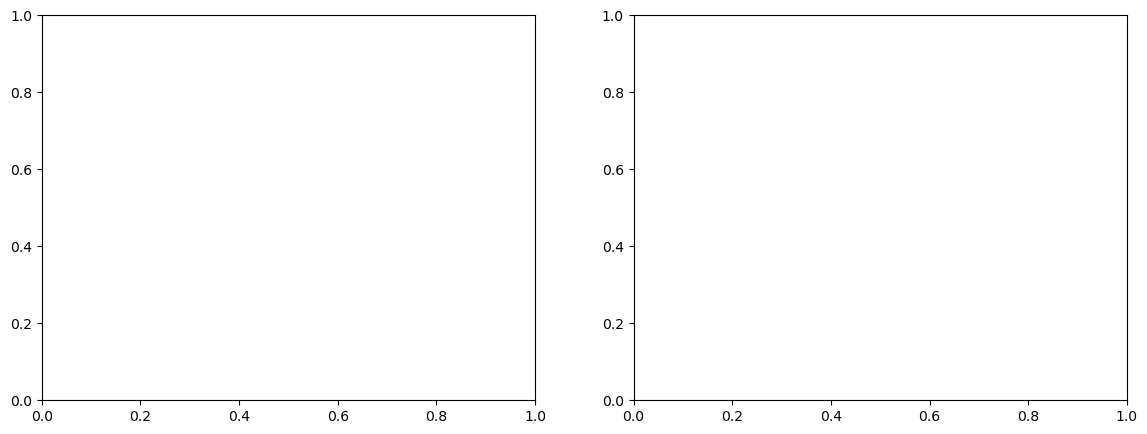

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df2_clean, x='final_score', hue='uses_ai', bins=30,
             kde=True, ax=axes[0], palette=['steelblue', 'tomato'])
axes[0].set_title('Final Score Distribution: AI Users vs Non-AI Users')
axes[0].set_xlabel('Final Score')
axes[0].set_ylabel('Count')

df2_clean['ai_bin'] = pd.cut(df2_clean['ai_generated_content_percentage'], bins=5)
bin_means = df2_clean.groupby('ai_bin')['final_score'].mean()
bin_means.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Average Final Score by AI-Generated Content Level')
axes[1].set_xlabel('% of Assignments AI-Generated')
axes[1].set_ylabel('Mean Final Score')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Key observations:**

- The distribution of final scores for AI users and non-AI users is nearly identical, suggesting that *whether* a student uses AI is not a strong predictor of their final score on its own.
- However, the bar chart reveals a clear downward trend: as the percentage of AI-generated assignment content increases, average final scores decline. This pattern suggests that *how* AI is used matters more than whether it is used at all.

This motivates our OLS analysis in the next section, where we formally test AI-related predictors.

---

## Analysis

### Analysis 1 — OLS Regression: AI Variables and Final Score (Dataset 2)

We run two OLS regressions on Dataset 2. First, a simple model using only `uses_ai` to test whether simply being an AI user predicts final score. Second, a multivariate model including all main AI usage variables.

In [ ]:
# Model 1
X1 = sm.add_constant(df2_clean[['uses_ai']])
y2 = df2_clean['final_score']
model1 = sm.OLS(y2, X1).fit()
print('=== Model 1: uses_ai only ===')
print(model1.summary())

print('\n')

# Model 2
X2 = sm.add_constant(df2_clean[[
    'ai_dependency_score',
    'ai_generated_content_percentage',
    'ai_prompts_per_week',
    'ai_usage_time_minutes'
]])
model2 = sm.OLS(y2, X2).fit()
print('=== Model 2: AI feature variables ===')
print(model2.summary())

**Model 1:**  
Simply using AI tools has essentially no relationship with final score. The R² is effectively zero and the F-statistic is not significant. This confirms our hypothesis that *whether* a student uses AI is not predictive of performance.

**Model 2:**  
Looking at specific AI beahviors gives a clearer understanding of how AI affects grades: 
- ai_generated_content_percentage is the only factor that significantly affects final scores. This means that for every 1% increase in AI-generated content in an assignment, the final score drops by about 0.044 points.
- ai_dependency_score, ai_prompts_per_week, and ai_usage_time_minutes do not have a significant impact on grades (p > 0.05).
- R² ≈ 0.010, which means AI-related variables explain only about 1% of the differences in students’ final scores. So AI usage has a small but noticeable effect on academic performance.

> **Takeaway:** The issue isn’t using AI itself, it’s replacing your own work with AI-generated content. When students submit AI-generated work as their own, their final scores tend to be lower, probably because they miss out on the learning process.

### Analysis 2 — Full Multivariate OLS: All Predictors of Final Score (Dataset 2)

We now fit a full OLS model using all relevant behavioral, AI, and demographic predictors to identify the complete picture of what drives final scores.

In [ ]:
drop_cols = ['student_id', 'passed', 'performance_category',
             'grade_level', 'gender', 'last_exam_score', 'assignment_scores_avg']
df_model2 = df2_clean.drop(columns=drop_cols, errors='ignore')

df_model2 = pd.get_dummies(df_model2, drop_first=True)

X_full = sm.add_constant(df_model2.drop(columns=['final_score']))
y_full = df_model2['final_score']

model_full = sm.OLS(y_full, X_full).fit()
print(model_full.summary())

**Full OLS Results:**

Main findings: 

| `concept_understanding_score` | **Strongest predictor.** For every 1 point increase in understanding the concepts, the final score increases by about 2 points. |
| `ai_generated_content_percentage` | More AI-generated work → lower scores. |
| `study_hours_per_day` | Positive but not significant; understanding the material matters more than just studying longer. |
| `attendance_percentage` | Non-significant in this model, may happen because attendance already affects other factors like understanding. |
| `uses_ai` | Not significant — confirms Model 1 finding. |
| `sleep_hours`, `social_media_hours` | Not significant in this dataset. |

**Key insight:** The most important factor for good grades is actually understanding the material. Using AI is not the problem. The real issue is relying too much on AI-generated work instead of learning the concepts yourself, which is linked to lower scores.

### Analysis 3 — Study Habit Correlations and Group Comparisons (Dataset 2)

We examine how core study habits correlate with final score, and whether AI users and non-AI users differ meaningfully in their study behaviors.

In [ ]:
study_vars = ['study_hours_per_day', 'study_consistency_index', 'attendance_percentage',
              'class_participation_score', 'sleep_hours', 'social_media_hours', 'final_score']

corr_matrix = df2_clean[study_vars].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix: Study Habits and Final Score (Dataset 2)')
plt.tight_layout()
plt.show()

# t-test: do AI users and non-AI users differ in study hours?
ai_users_study = df2_clean[df2_clean['uses_ai'] == 1]['study_hours_per_day']
non_ai_study = df2_clean[df2_clean['uses_ai'] == 0]['study_hours_per_day']
t_stat, p_val = ttest_ind(ai_users_study, non_ai_study, equal_var=False)
print(f'\nt-test (study hours: AI vs non-AI users):')
print(f'  t-statistic = {t_stat:.4f}, p-value = {p_val:.4f}')
print(f'  Mean study hours (AI users): {ai_users_study.mean():.2f}')
print(f'  Mean study hours (non-AI users): {non_ai_study.mean():.2f}')

**Study habit correlations with final score (Dataset 2)**: 

In this dataset common study habits like: 
- study hours
- attendance
- sleep 
- social media use

do not show a strong connection with final scores. 

This is surprising because in Dataset 1, missing class had a very strong negative effect on grades. 

A likely explanation is concept_understanding_score.
Students who study effectively understand the concepts better, and that understanding is what improves their grades. 

Because of this, when concept understanding is included in the model, the direct effects of studying more or attending class become smaller. 

*Study Hours and AI Usage*

A t-test showed no significant difference in study hours between: 
- students who use AI
- students who do not use AI
This means AI users are not studying less. 

The lower scores linked to AI-generated content are probably not about how long students study, but about how they learn and engage with the material. 

## Ethics

Our team has carefully considered ethical implications across the full lifecycle of this project, including data collection, storage, analysis, modeling, and potential deployment.

---

### A. Data Collection

#### A.1 Informed Consent — Considered ✓
We will only use publicly available datasets that were collected with appropriate consent for academic research. Dataset documentation will be reviewed to confirm ethical collection practices before any data is used.

#### A.2 Collection Bias — Considered ✓
Survey-based student datasets may contain self-selection bias. Students who choose to participate may differ from those who do not. We acknowledge that this may limit generalizability and will clearly state this limitation in our report.

#### A.3 Limit PII Exposure — Considered ✓
We will only use datasets that are anonymized and do not include personally identifiable information (PII). Identity-level data such as names, emails, or IDs are not necessary for our analysis and will not be used.

#### A.4 Downstream Bias Mitigation — Considered ✓
If demographic variables are included, we will use them carefully to test for fairness rather than to reinforce stereotypes.

---

### B. Data Storage

#### B.1 Data Security — Considered ✓
We will not share raw data beyond what is publicly available from the original source.

#### B.2 Right to Be Forgotten — Considered ✓
Because we are not collecting new data and will only use anonymized public datasets, individual removal requests are not applicable to this project.

#### B.3 Data Retention Plan — Considered ✓
The dataset will only be used for the duration of this course project. We do not plan to retain or reuse the data beyond academic purposes.

---

### C. Analysis

#### C.1 Missing Perspectives — Considered ✓
We recognize that our team may not represent all student experiences. We rely on prior research and will clearly state limitations in interpretation.

#### C.2 Dataset Bias — Considered ✓
We will examine variable distributions and discuss possible biases and potential confounding factors.

#### C.3 Honest Representation — Considered ✓
All visualizations and statistical summaries will accurately represent the data. We will avoid misleading scales and clearly label all figures.

#### C.4 Privacy in Analysis — Considered ✓
We will not display or analyze any personally identifiable information.

#### C.5 Auditability — Considered ✓
All data cleaning and modeling steps will be documented in our notebook to ensure transparency and reproducibility.

---

### D. Modeling

#### D.1 Proxy Discrimination — Considered ✓
We will examine whether any variables may unintentionally act as proxies for protected characteristics and interpret results carefully.

#### D.2 Fairness Across Groups — Considered ✓
We will evaluate whether predictive performance differs across demographic groups.

#### D.3 Metric Selection — Considered ✓
We will use appropriate regression metrics and clearly explain why they were selected.

#### D.4 Explainability — Considered ✓
We will use interpretable methods and explain results in accessible language.

#### D.5 Communicate Limitations — Considered ✓
We will clearly state that our findings demonstrate associations rather than causation, and we will discuss dataset and modeling limitations.

---

### E. Deployment

#### E.1 Monitoring and Evaluation — Considered ✓
This is an academic project and will not be deployed in a real-world setting.

#### E.2 Redress — Considered ✓
Since the model will not be used for real decision-making, direct harm is unlikely.

#### E.3 Roll Back — Considered ✓
The model exists only within our project notebook and can be easily modified or removed.

#### E.4 Unintended Use — Considered ✓
We will clearly state that this model is for educational purposes only and should not be used for high-stakes decisions about students.


## Discusison and Conclusion

This project aimed to understand which factors best predict student academic performance, focusing on study habits, attendance, and, the use of AI tools. Across both datasets, a consistent pattern emerged: the quality and consistency of genuine academic engagement matter more than any single behavioral or technological factor.

In Dataset 1, absences were the strongest predictor of GPA, with a very strong negative correlation. This indicates that students who miss more classes tend to have significantly lower GPAs. Study time showed a statistically significant but relatively small positive relationship with GPA, suggesting that studying does help, but by itself explains only a small portion of academic performance. Parental support and tutoring were positively associated with GPA, while demographic factors such as gender and age showed almost no correlation. These findings support previous research identifying attendance as a key behavioral predictor of academic success (Credé et al., 2010).

In Dataset 2, the results highlighted the importance of cognitive engagement. The variable concept_understanding_score was the strongest predictor of final grades, contributing most of the explanatory power in the model. In contrast, simply using AI tools was not significantly related to academic performance. However, the percentage of AI-generated assignment content was consistently associated with lower final scores. This suggests that the issue is not AI use itself, but rather the tendency to rely on AI to replace independent thinking instead of using it as a learning aid.

These findings connect closely with previous research discussed in the background. The strong role of attendance aligns with findings by Credé et al. (2010), who identified attendance as one of the most reliable predictors of academic success. Similarly, prior studies have shown that passive or distracting digital behaviors, such as excessive gaming or screen time, can reduce academic engagement (Anand, 2017). Our results extend this idea to AI tools: similar to other technologies, their impact depends on how they are used. When AI replaces the effort required to learn concepts, academic performance appears to decline.

Despite these insights, this study has several limitations. First, both datasets appear to be synthetic or highly structured rather than raw observational data, which may make the relationships between variables clearer than they would be in real-world data. Second, Dataset 1 focuses on high school students aged 15–18, while the broader research question relates to higher education, limiting how directly the findings can be generalized to college populations. Third, several variables rely on self-reported behavior, such as study hours and AI usage time, which may introduce reporting bias. Finally, the analysis is cross-sectional, meaning it cannot establish causal relationships. For example, it is possible that struggling students turn to AI-generated content more frequently, rather than AI usage causing lower performance.

Future research could build on this work in several ways. More advanced predictive models, such as regularized regression methods or tree-based models, could improve prediction accuracy and help handle correlations between variables. Researchers could also explore interaction effects, such as whether AI usage affects students with different levels of academic ability in different ways. Longitudinal studies that follow students across multiple semesters would be particularly valuable, as they could reveal how AI usage and study behaviors influence performance over time.

Overall, the results suggest that academic success is driven primarily by meaningful engagement with course material. Attending class, developing conceptual understanding, and actively participating in the learning process are the most consistent predictors of performance across the datasets analyzed. AI tools themselves are neither inherently beneficial nor harmful; however, relying on them to substitute for independent thinking appears to negatively affect learning outcomes. As AI becomes more integrated into education, the challenge for students and educators will be to use these tools in ways that support learning rather than replace it.